In [1]:
import os
from tqdm import tqdm
import glob
from rdkit import Chem
from rdkit.Chem import AllChem
import re
import subprocess
from shutil import copyfile
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [2]:
df = pd.read_csv('all.csv')

In [3]:
df.shape

(363582, 13)

In [4]:
df[df['Mgltools_nrb'] == 1].shape

(2423, 13)

In [5]:
df = df[df['mgltools_energy'] < -8]

In [6]:
candidates = []

for n in range(0, 17):
    to_add = []
    temp = df[df['Mgltools_nrb'] == n][['Pubchem_id', 'molwt']].sort_values(by=['molwt']).reset_index(drop=True)
    pub_ids = list(temp['Pubchem_id'])
    molwts = list(temp['molwt'])
    temp_size = len(temp) - 1
    for i in range(0, 100):
        curr_row = temp.iloc[int(i*temp_size/99)]
        to_add.append((int(curr_row[0]), curr_row[1]))
    candidates.append((n, to_add))

In [ ]:
candidates

In [ ]:
for i in candidates:
    nrb = i[0]
    for j in i[1]:
        copyfile(glob.glob('ligands_min/*/*' + str(j[0]) + '.pdbqt')[0], 'candidates/' + str(j[0]) + '_' + str(nrb) + '.pdbqt')

In [8]:
l_id = []
for i in candidates:
    nrb = i[0]
    for j in i[1]:
        l_id.append(j[0])

In [9]:
df_test = df[df['Pubchem_id'].isin(l_id)].copy(deep=True)

In [10]:
df_test

,Pubchem_id,Mgltools_nrb,Babel_nrb,NRB_pubchem,Mgltools-Babel,Mgltools-Rdkit,Mgltools-Pubchem,Babel-Rdkit,Babel-Pubchem,mgltools_energy,babel_energy,energy_delta,molwt
11,134337937,2,1.0,2.0,1.0,0.0,0.0,-1.0,-1.0,-11.4,0.1,-11.5,611.199762
23,134605202,4,3.0,4.0,1.0,0.0,0.0,-1.0,-1.0,-12.0,-1.7,-10.3,624.231397
43,118602286,3,2.0,3.0,1.0,0.0,0.0,-1.0,-1.0,-12.0,-3.1,-8.9,609.133340
183,90062460,4,3.0,4.0,1.0,0.0,0.0,-1.0,-1.0,-10.9,-4.9,-6.0,612.231397
272,148225663,1,1.0,2.0,0.0,-1.0,-1.0,-1.0,-1.0,-10.7,-5.3,-5.4,586.190595
...,...,...,...,...,...,...,...,...,...,...,...,...,...
362760,129297140,1,0.0,1.0,1.0,0.0,0.0,-1.0,-1.0,-8.7,-11.4,2.7,535.168462
362936,148671865,2,1.0,2.0,1.0,0.0,0.0,-1.0,-1.0,-9.1,-12.0,2.9,584.112939
363084,153469972,2,1.0,2.0,1.0,0.0,0.0,-1.0,-1.0,-8.3,-11.5,3.2,640.189926
363206,130258311,1,0.0,1.0,1.0,0.0,0.0,-1.0,-1.0,-8.2,-11.6,3.4,624.231397


In [11]:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 
 12, 14, 16, 18, 20, 24, 28, 32, 36, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100]

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 12,
 14,
 16,
 18,
 20,
 24,
 28,
 32,
 36,
 40,
 45,
 50,
 55,
 60,
 65,
 70,
 80,
 90,
 100]

In [13]:
def doit(d):
    file_names = glob.glob(d + '/*/*.pdbqt')
    everything = {}
    failures = []
    print('Found', len(file_names), 'pdbqt files')
    for file_name in file_names:
        file = open(file_name)
        lines = file.readlines()
        file.close()
        try:
            line = lines[1]
            result = float(line.split(':')[1].split()[0])
            compound_id = file_name.split('/')[-1].split('id')[-1].split('_')[0]
            everything[compound_id] = (result, file_name)
        except:
            failures.append(file_name)
    
    if len(failures) > 0:
        print('WARNING:', len(failures), 'pdbqt files could not be processed')
    
    return everything

In [14]:
results_dir = 'results_new'
logs_dir = 'logs'

In [15]:
d_ex_lel = {}

for exh in os.listdir(results_dir):
    if '_' not in exh:
        continue
    d_ex_loc = doit(results_dir + '/' + exh)
    for key in d_ex_loc:
        if key in d_ex_lel:
            d_ex_lel[key][int(exh)] = d_ex_loc[key][0]
        else:
            d_ex_lel[key] = { int(exh) : d_ex_loc[key][0]}
    #df_test[exh] = df_test['Pubchem_id'].apply(lambda x: d_ex[str(x)] if str(x) in d_ex else print("DICT WARNING")) 

Found 1700 pdbqt files
Found 1700 pdbqt files


In [16]:
d_ex_lel

{'139423206': {1003: -11.9, 1002: -11.9},
 '148671865': {1003: -9.1, 1002: -9.1},
 '89632638': {1003: -8.5, 1002: -8.5},
 '155152303': {1003: -7.8, 1002: -7.8},
 '91408562': {1003: -8.8, 1002: -8.8},
 '129845265': {1003: -8.5, 1002: -8.5},
 '134238372': {1003: -7.6, 1002: -8.3},
 '123542221': {1003: -9.0, 1002: -9.0},
 '32184735': {1003: -9.2, 1002: -9.2},
 '46865854': {1003: -9.5, 1002: -9.5},
 '88952158': {1003: -8.9, 1002: -8.9},
 '118726081': {1003: -9.8, 1002: -9.8},
 '68700422': {1003: -9.8, 1002: -9.8},
 '140596080': {1003: -8.2, 1002: -8.2},
 '22156121': {1003: -8.8, 1002: -8.8},
 '59127077': {1003: -9.4, 1002: -9.9},
 '140913825': {1003: -9.8, 1002: -9.8},
 '56649378': {1003: -10.1, 1002: -10.1},
 '68187327': {1003: -8.1, 1002: -8.2},
 '112892158': {1003: -9.0, 1002: -9.1},
 '112904803': {1003: -8.4, 1002: -8.4},
 '143258991': {1003: -8.6, 1002: -8.6},
 '141714852': {1003: -9.0, 1002: -9.1},
 '143490598': {1003: -8.8, 1002: -8.6},
 '67047483': {1003: -9.8, 1002: -9.8},
 '14843

In [17]:
d_ex = {}

for exh in os.listdir(results_dir):
    if '_' in exh:
        continue
    d_ex_loc = doit(results_dir + '/' + exh)
    for key in d_ex_loc:
        if key in d_ex:
            d_ex[key][int(exh)] = d_ex_loc[key][0]
        else:
            d_ex[key] = { int(exh) : d_ex_loc[key][0]}
    #df_test[exh] = df_test['Pubchem_id'].apply(lambda x: d_ex[str(x)] if str(x) in d_ex else print("DICT WARNING")) 

Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 pdbqt files
Found 1700 

In [18]:
for log_file in glob.glob(logs_dir + '/*.txt'):
    f = open(log_file, 'r')
    lines = f.read().split('\n')
    lines.remove('')
    f.close()
    exh = int(os.path.basename(log_file).split('.')[0])
    
    for line in lines:
        pub_id = line.split()[2].split('/')[-1].split('_')[0]
        exec_time = float(line.split()[-2])
        energy = d_ex[pub_id][exh]
        d_ex[pub_id][exh] = (energy, exec_time)

In [19]:
df_test[['Pubchem_id', 'mgltools_energy']].apply(lambda x: abs(d_ex[str(int(x[0]))][100][0] - x[1]),axis=1).mean()

0.09958823529411767

In [20]:
sum([abs(d_ex_lel[key][1003] - d_ex[key][100][0]) for key in d_ex_lel]) / 1700

0.10170588235294035

In [21]:
exh_list = []

for key in d_ex['139423206']:
    exh_list.append(key)
    
exh_list

[68,
 10,
 40,
 100,
 85,
 4,
 32,
 44,
 8,
 60,
 80,
 64,
 1,
 24,
 9,
 15,
 17,
 26,
 22,
 2,
 48,
 19,
 13,
 6,
 56,
 16,
 3,
 38,
 76,
 52,
 11,
 34,
 5,
 14,
 12,
 18,
 95,
 36,
 20,
 90,
 30,
 7,
 72,
 28]

In [22]:
df_test['info'] = df_test['Pubchem_id'].apply(lambda x: d_ex[str(x)] if str(x) in d_ex else print('DICT WARNING'))

In [23]:
df_test = df_test.reset_index(drop=True)

In [24]:
df_test

,Pubchem_id,Mgltools_nrb,Babel_nrb,NRB_pubchem,Mgltools-Babel,Mgltools-Rdkit,Mgltools-Pubchem,Babel-Rdkit,Babel-Pubchem,mgltools_energy,babel_energy,energy_delta,molwt,info
0,134337937,2,1.0,2.0,1.0,0.0,0.0,-1.0,-1.0,-11.4,0.1,-11.5,611.199762,"{68: (-11.4, 382.538020134), 10: (-5.1, 59.548..."
1,134605202,4,3.0,4.0,1.0,0.0,0.0,-1.0,-1.0,-12.0,-1.7,-10.3,624.231397,"{68: (-11.6, 346.01134491), 10: (-6.2, 46.3761..."
2,118602286,3,2.0,3.0,1.0,0.0,0.0,-1.0,-1.0,-12.0,-3.1,-8.9,609.133340,"{68: (-12.0, 252.540904999), 10: (-12.0, 37.35..."
3,90062460,4,3.0,4.0,1.0,0.0,0.0,-1.0,-1.0,-10.9,-4.9,-6.0,612.231397,"{68: (-11.1, 362.651329041), 10: (-10.7, 54.29..."
4,148225663,1,1.0,2.0,0.0,-1.0,-1.0,-1.0,-1.0,-10.7,-5.3,-5.4,586.190595,"{68: (-10.2, 290.458906174), 10: (-10.6, 48.65..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,129297140,1,0.0,1.0,1.0,0.0,0.0,-1.0,-1.0,-8.7,-11.4,2.7,535.168462,"{68: (-8.7, 282.345464945), 10: (-8.7, 41.1114..."
1696,148671865,2,1.0,2.0,1.0,0.0,0.0,-1.0,-1.0,-9.1,-12.0,2.9,584.112939,"{68: (-9.1, 340.799281836), 10: (-8.0, 51.1491..."
1697,153469972,2,1.0,2.0,1.0,0.0,0.0,-1.0,-1.0,-8.3,-11.5,3.2,640.189926,"{68: (-8.7, 410.441063881), 10: (-6.6, 57.2610..."
1698,130258311,1,0.0,1.0,1.0,0.0,0.0,-1.0,-1.0,-8.2,-11.6,3.4,624.231397,"{68: (-8.1, 333.77344203), 10: (-8.1, 48.40106..."


In [25]:
df_test.iloc[0]['info'][1]

(-5.1, 6.02109003067)

In [26]:
exh_list.sort()

In [27]:
y = []

for i in exh_list:
    y.append(df_test['info'].apply(lambda g: g[i][1]))
    

In [28]:
compounds_num = 1700

In [29]:
tendency = []

for i in range(0, 1700):
    line = []
    for ex in range(0, len(exh_list)):
        line.append(y[ex][i] / y[0][i])
    tendency.append(line)

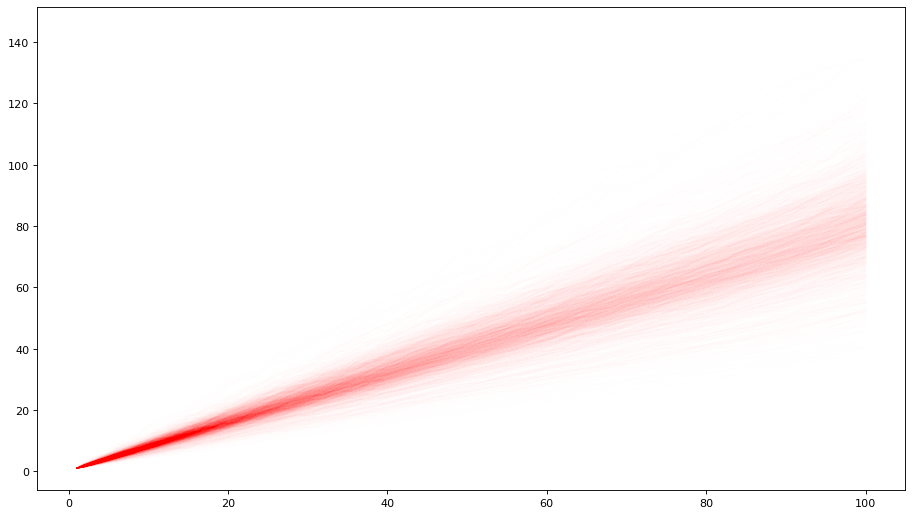

In [30]:
figure(figsize=(14, 8), dpi=80)  
for i in range(0, 1700):
    plt.plot(exh_list, tendency[i], color = '#ff0000', alpha = 0.005)
plt.show()

In [31]:
def get_norm(x):
    info = list(x['info'])
    molwt = list(x['molwt'])
    return [(info[i][100][1], molwt[i]) for i in range(len(x))]
    

In [32]:
data = df_test.groupby('Mgltools_nrb')[['info', 'molwt']].apply(lambda x: get_norm(x))

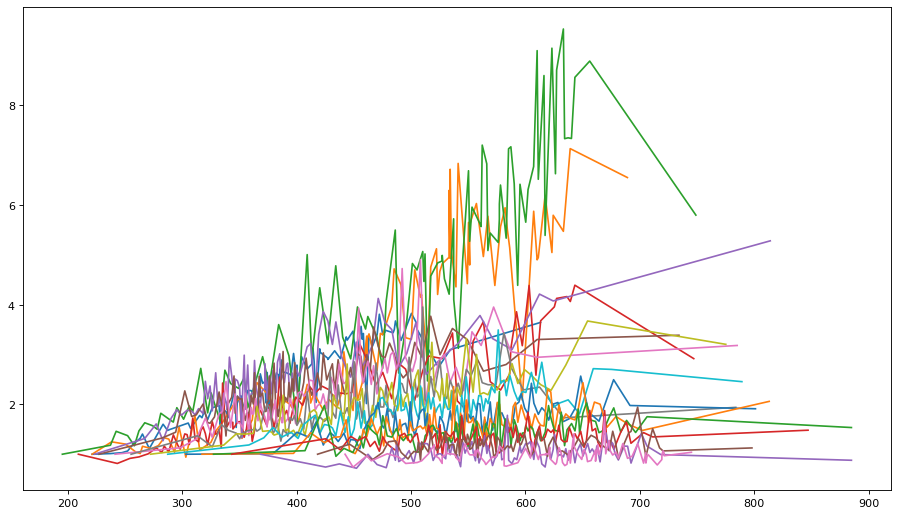

In [33]:
figure(figsize=(14, 8), dpi=80)  
for i in range(0, 17):
    data[i].sort(key = lambda x: x[1])
    l1, l2 = [list(i) for i in zip(*data[i])]
    norm = l1[0]
    for j in range(len(l1)):
        l1[j] = l1[j] / norm
    plt.plot(l2, l1)
plt.show()

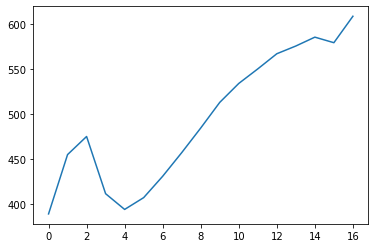

In [34]:
average_mass = []

for i in range(0, 17):
    average_mass.append(sum([x[1] for x in data[i]]) / 100)

plt.plot(range(0, 17), average_mass)
plt.show()

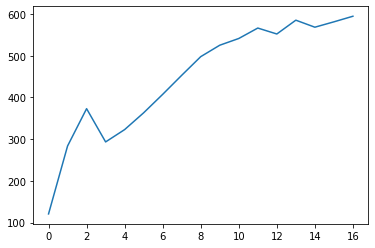

In [35]:
average_time = []

for i in range(0, 17):
    average_time.append(sum([x[0] for x in data[i]]) / len(data[i]))

plt.plot(range(0, 17), average_time)
plt.show()

In [36]:
df_test[df_test['info'].apply(lambda x: True if type(x[6][0]) is tuple else False)]

,Pubchem_id,Mgltools_nrb,Babel_nrb,NRB_pubchem,Mgltools-Babel,Mgltools-Rdkit,Mgltools-Pubchem,Babel-Rdkit,Babel-Pubchem,mgltools_energy,babel_energy,energy_delta,molwt,info


In [37]:
df_test.iloc[0]['info']

{68: (-11.4, 382.538020134),
 10: (-5.1, 59.5483350754),
 40: (-11.4, 228.218913078),
 100: (-11.4, 551.018131971),
 85: (-11.1, 474.78965497),
 4: (-6.0, 28.8811969757),
 32: (-6.1, 181.903164864),
 44: (-11.4, 249.410364866),
 8: (-5.1, 41.0070011616),
 60: (-11.4, 334.077125072),
 80: (-11.4, 456.121176004),
 64: (-11.4, 358.92947197),
 1: (-5.1, 6.02109003067),
 24: (-11.4, 130.888891935),
 9: (-5.6, 58.1646151543),
 15: (-7.1, 79.5518889427),
 17: (-11.4, 86.6220710278),
 26: (-11.4, 153.024646044),
 22: (-7.1, 120.95149684),
 2: (-11.4, 13.8082199097),
 48: (-11.4, 278.539653063),
 19: (-11.4, 105.43276906),
 13: (-8.4, 70.078305006),
 6: (-7.1, 36.2473421097),
 56: (-11.4, 315.388375044),
 16: (-11.4, 83.9003031254),
 3: (-5.1, 15.4621450901),
 38: (-11.4, 212.956430912),
 76: (-11.4, 431.093862057),
 52: (-11.4, 285.963268995),
 11: (-11.4, 65.6965048313),
 34: (-11.4, 186.684608936),
 5: (-11.4, 26.8863818645),
 14: (-5.8, 78.9148640633),
 12: (-5.9, 60.7121679783),
 18: (-11.

In [38]:
def get_norm2(x):
    print(len(x))
    info = list(x['info'])
    energy = list(x['mgltools_energy'])
    res_mean = []
    res_var = []
    for ex in exh_list:
        mean = sum([info[i][ex][0] for i in range(len(info))]) / 100
        var = (sum([abs(info[i][ex][0] - energy[i]) for i in range(len(info))]) / 100 )
        res_mean.append(mean)
        res_var.append(var)
    return (res_mean, res_var)
    

In [39]:
nrb_energy = df_test.groupby('Mgltools_nrb')[['info', 'mgltools_energy']].apply(lambda x: get_norm2(x))

100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100


In [40]:
nrb_energy[0]

([-7.542000000000006,
  -7.862000000000002,
  -8.001000000000005,
  -8.202000000000002,
  -8.396000000000006,
  -8.380000000000006,
  -8.451000000000006,
  -8.522000000000004,
  -8.453000000000005,
  -8.543000000000006,
  -8.498000000000006,
  -8.549000000000007,
  -8.550000000000008,
  -8.562000000000006,
  -8.573000000000006,
  -8.554000000000006,
  -8.576000000000006,
  -8.546000000000005,
  -8.583000000000007,
  -8.563000000000006,
  -8.602000000000006,
  -8.598000000000006,
  -8.589000000000008,
  -8.610000000000007,
  -8.624000000000008,
  -8.592000000000008,
  -8.635000000000005,
  -8.587000000000007,
  -8.607000000000005,
  -8.609000000000005,
  -8.612000000000009,
  -8.608000000000006,
  -8.620000000000005,
  -8.626000000000007,
  -8.613000000000007,
  -8.636000000000006,
  -8.636000000000005,
  -8.640000000000006,
  -8.630000000000006,
  -8.640000000000008,
  -8.618000000000006,
  -8.639000000000005,
  -8.644000000000007,
  -8.617000000000006],
 [1.104,
  0.7860000000000004,


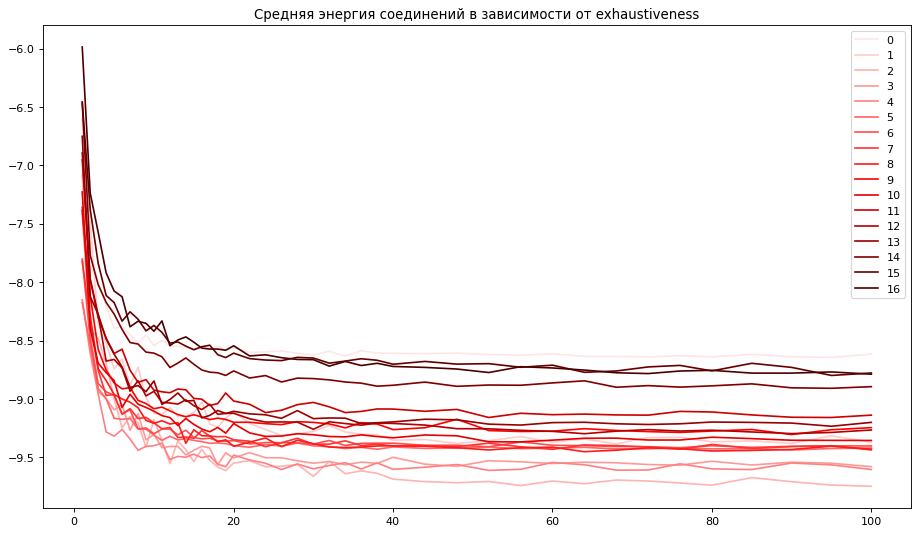

In [41]:
colors = ['#ffe6e6', '#ffcccc', '#ffb3b3', '#ff9999', '#ff8080', '#ff6666', '#ff4d4d', '#ff3333', '#ff1a1a', 
          '#ff0000', '#e60000', '#cc0000', '#b30000', '#990000', '#800000', '#660000', '#4d0000', '#330000']


figure(figsize=(14, 8), dpi=80)  
for i in range(0, 17):
    plt.plot(exh_list, nrb_energy[i][0], color = colors[i], label = str(i))

plt.title('Средняя энергия соединений в зависимости от exhaustiveness')
plt.legend()
plt.show()

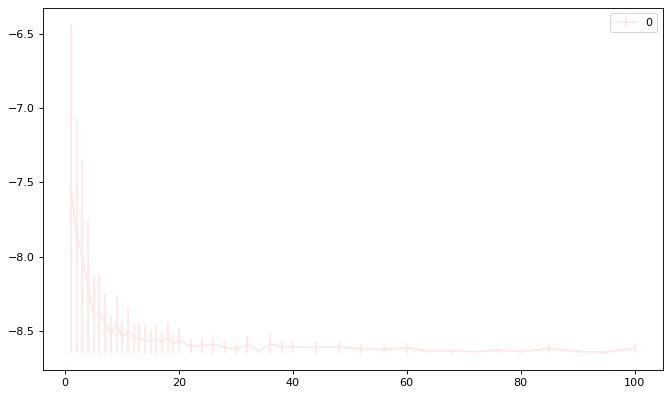

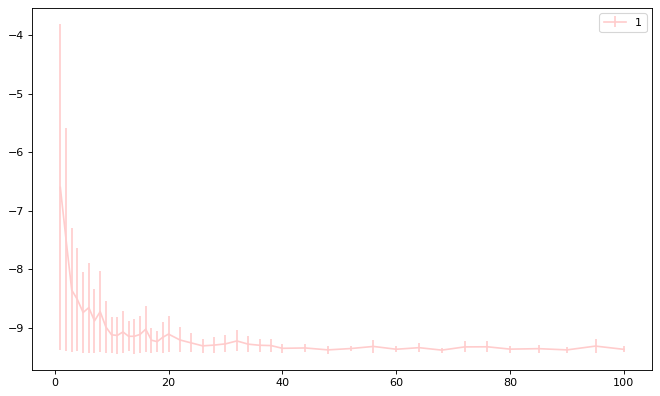

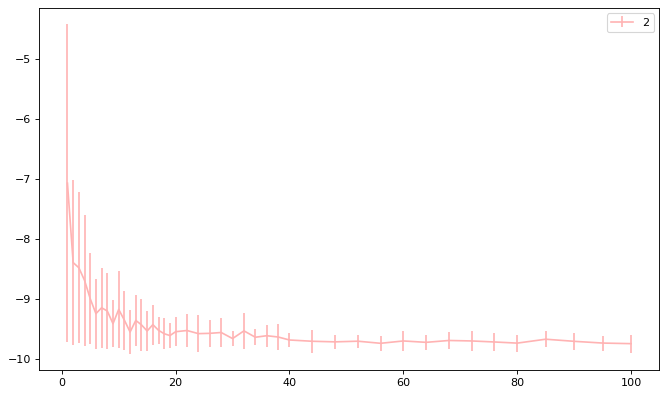

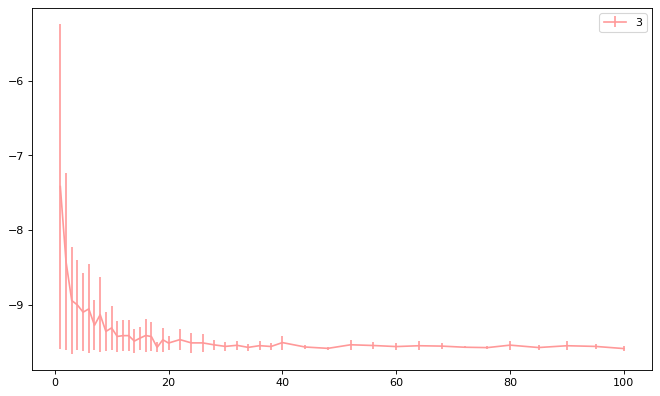

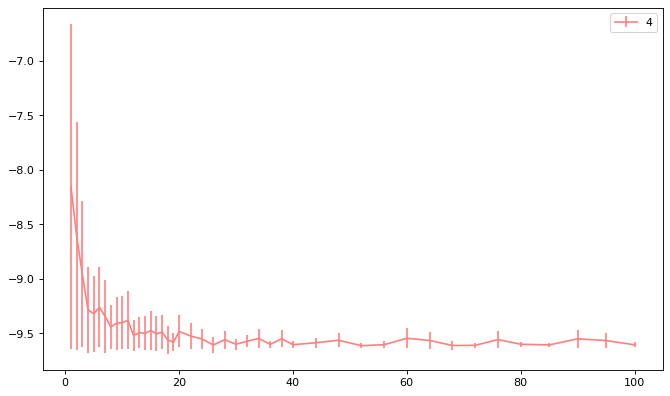

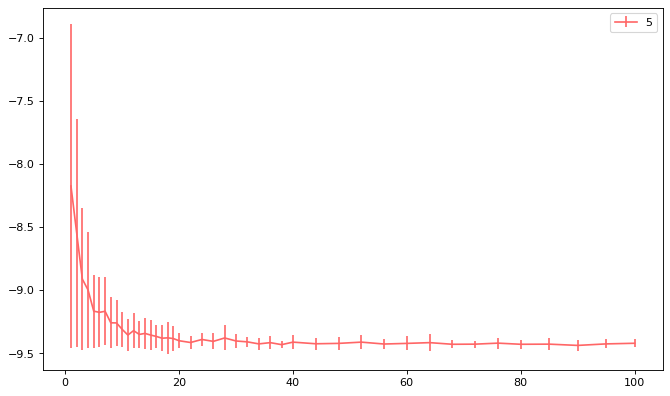

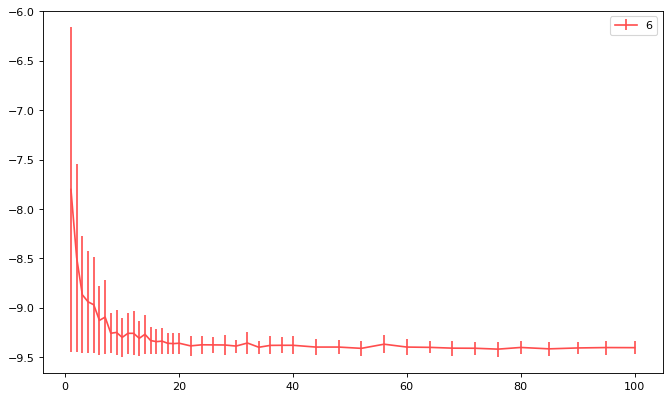

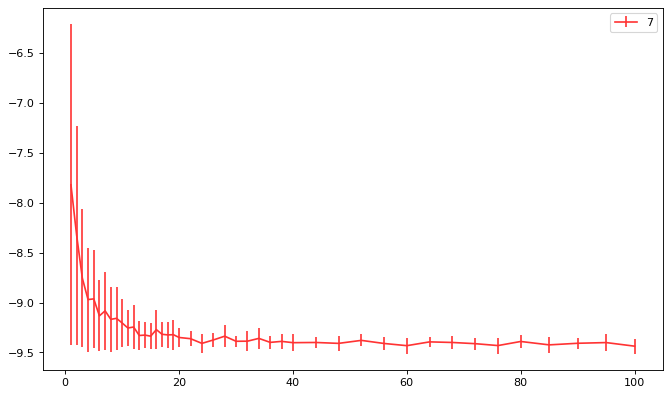

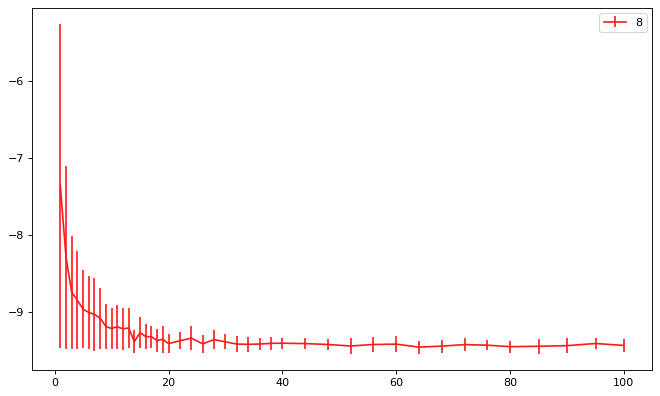

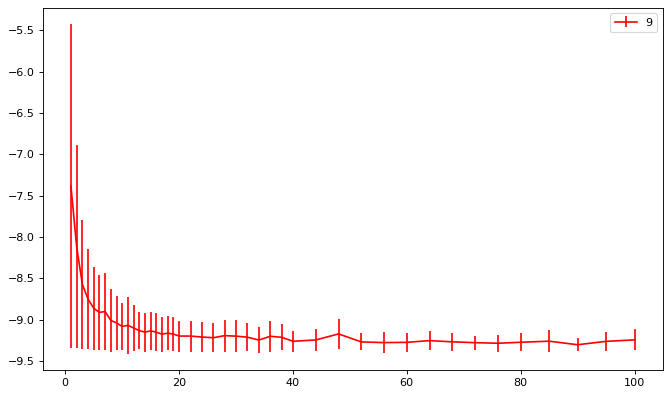

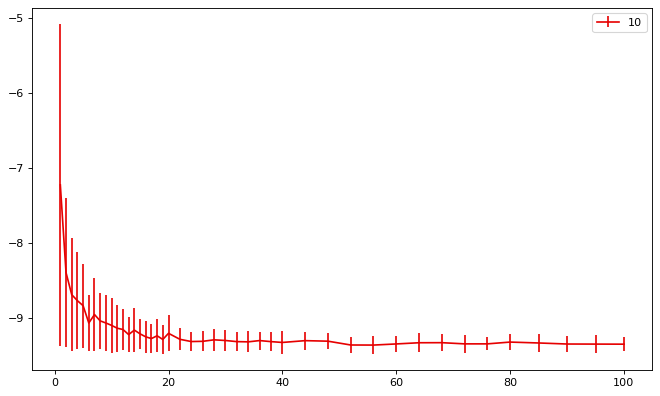

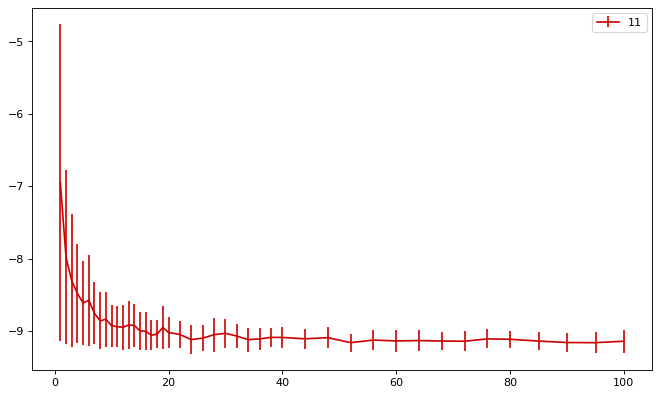

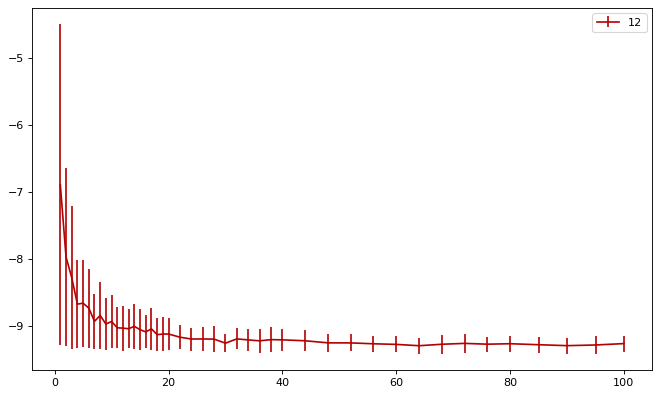

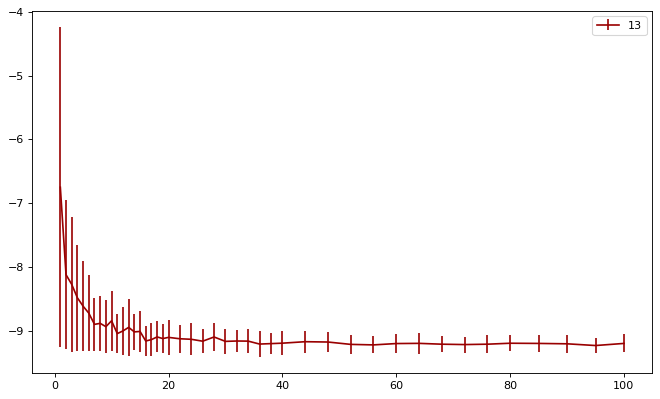

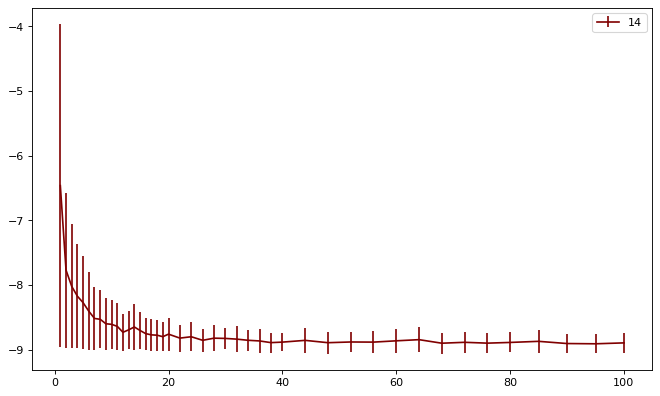

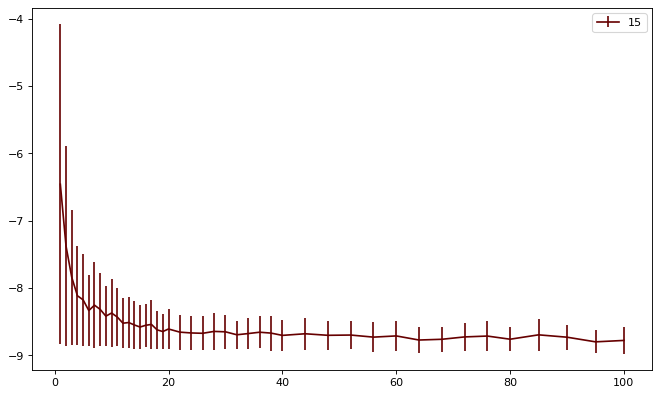

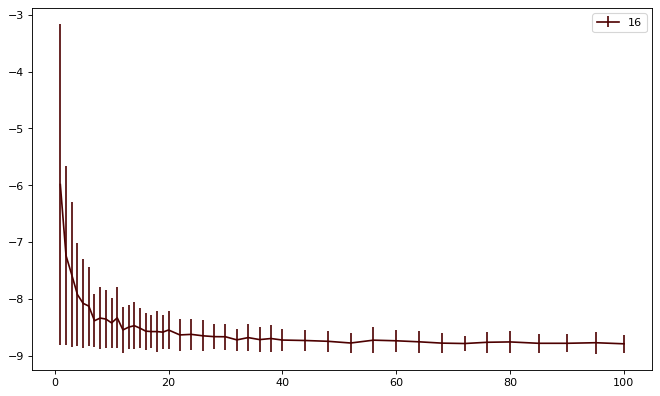

In [42]:
colors = ['#ffe6e6', '#ffcccc', '#ffb3b3', '#ff9999', '#ff8080', '#ff6666', '#ff4d4d', '#ff3333', '#ff1a1a', 
          '#ff0000', '#e60000', '#cc0000', '#b30000', '#990000', '#800000', '#660000', '#4d0000', '#330000']



for i in range(0, 17):
    figure(figsize=(10, 6), dpi=80)  
    plt.errorbar(exh_list, nrb_energy[i][0], nrb_energy[i][1], color = colors[i], label = str(i))
    plt.legend()
    plt.show()

<AxesSubplot:>

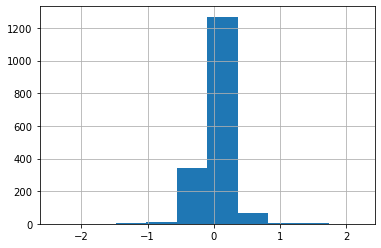

In [43]:
df_test[['Pubchem_id', 'mgltools_energy']].apply(lambda x: d_ex_lel[str(int(x[0]))][1002] - x[1],axis=1).hist()

In [45]:
m = []

for key in d_ex_lel:
    m.append((d_ex_lel[key][1002] - d_ex_lel[key][1003], key))

In [55]:
for key in d_ex:
    d_ex_lel[key][1004] = d_ex[key][100][0]

In [62]:
for row in df_test[['Pubchem_id', 'mgltools_energy']].values:
    d_ex_lel[str(int(row[0]))][1001] = row[1]

In [63]:
d_ex_lel

{'139423206': {1003: -11.9, 1002: -11.9, 1004: -11.9, 1001: -11.9},
 '148671865': {1003: -9.1, 1002: -9.1, 1004: -9.8, 1001: -9.1},
 '89632638': {1003: -8.5, 1002: -8.5, 1004: -8.5, 1001: -8.4},
 '155152303': {1003: -7.8, 1002: -7.8, 1004: -7.8, 1001: -8.2},
 '91408562': {1003: -8.8, 1002: -8.8, 1004: -8.8, 1001: -8.8},
 '129845265': {1003: -8.5, 1002: -8.5, 1004: -8.5, 1001: -8.5},
 '134238372': {1003: -7.6, 1002: -8.3, 1004: -8.3, 1001: -8.3},
 '123542221': {1003: -9.0, 1002: -9.0, 1004: -9.0, 1001: -9.1},
 '32184735': {1003: -9.2, 1002: -9.2, 1004: -9.2, 1001: -9.2},
 '46865854': {1003: -9.5, 1002: -9.5, 1004: -9.5, 1001: -9.5},
 '88952158': {1003: -8.9, 1002: -8.9, 1004: -8.9, 1001: -8.9},
 '118726081': {1003: -9.8, 1002: -9.8, 1004: -9.7, 1001: -9.8},
 '68700422': {1003: -9.8, 1002: -9.8, 1004: -9.8, 1001: -9.8},
 '140596080': {1003: -8.2, 1002: -8.2, 1004: -8.3, 1001: -8.2},
 '22156121': {1003: -8.8, 1002: -8.8, 1004: -8.8, 1001: -8.8},
 '59127077': {1003: -9.4, 1002: -9.9, 1004:

In [100]:
d_100 = {}
d_100['Pubchem_id'] = []
d_100['1'] = []
d_100['2'] = []
d_100['3'] = []
d_100['4'] = []

for key in d_ex_lel:
    d_100['Pubchem_id'].append(int(key))
    d_100['1'].append(d_ex_lel[key][1001])
    d_100['2'].append(d_ex_lel[key][1002])
    d_100['3'].append(d_ex_lel[key][1003])
    d_100['4'].append(d_ex_lel[key][1004])

In [101]:
df_100 = pd.DataFrame(d_100, columns=['Pubchem_id', '1', '2', '3', '4'])

In [102]:
df_100['1-2'] = df_100[['1', '2']].min(axis=1)
df_100['3-4'] = df_100[['3', '4']].min(axis=1)

In [103]:
df_100['1234'] = df_100['1-2'] - df_100['3-4']

In [107]:
heh = pd.merge(df_100, df_test[['Pubchem_id', 'Mgltools_nrb']])

In [108]:
heh.sort_values('1234')

,Pubchem_id,1,2,3,4,1-2,3-4,1234,Mgltools_nrb
1266,962705,-10.7,-9.0,-8.9,-9.1,-10.7,-9.1,-1.6,6
1505,155431514,-8.3,-9.1,-7.7,-6.7,-9.1,-7.7,-1.4,9
397,18315847,-9.2,-7.8,-7.8,-7.8,-9.2,-7.8,-1.4,9
626,144572973,-9.0,-8.3,-7.9,-8.0,-9.0,-8.0,-1.0,13
1347,49833237,-9.4,-8.6,-8.4,-8.5,-9.4,-8.5,-0.9,11
...,...,...,...,...,...,...,...,...,...
1,148671865,-9.1,-9.1,-9.1,-9.8,-9.1,-9.8,0.7,2
1499,49822125,-9.4,-9.5,-10.3,-10.3,-9.5,-10.3,0.8,10
317,118672664,-9.0,-9.0,-9.8,-9.8,-9.0,-9.8,0.8,2
1522,67006286,-9.3,-10.3,-11.5,-10.6,-10.3,-11.5,1.2,8


In [114]:
import numpy as np

def get_delta(x):
    l = list(x)
    idx = np.argmin(l)
    m = 100
    for i in range(4):
        if i != idx:
            m = min(m, abs(l[idx] - l[i]))
    return m

In [117]:
heh['omygar'] = heh[['1', '2', '3', '4']].apply(lambda x: get_delta(x),axis=1)

In [120]:
heh.sort_values('omygar').tail(20)

,Pubchem_id,1,2,3,4,1-2,3-4,1234,Mgltools_nrb,omygar
192,150092453,-8.9,-8.4,-8.4,-8.2,-8.9,-8.4,-0.5,15,0.5
177,155239344,-8.1,-8.6,-8.1,-8.0,-8.6,-8.1,-0.5,12,0.5
40,135210291,-8.5,-7.7,-7.7,-7.9,-8.5,-7.9,-0.6,15,0.6
356,149107149,-8.9,-9.0,-8.9,-9.6,-9.0,-9.6,0.6,3,0.6
146,23544432,-9.3,-8.7,-8.6,-8.7,-9.3,-8.7,-0.6,13,0.6
470,141454075,-8.2,-8.8,-8.2,-8.2,-8.8,-8.2,-0.6,16,0.6
256,142997603,-8.6,-8.7,-8.5,-9.3,-8.7,-9.3,0.6,13,0.6
581,68811313,-8.4,-8.1,-8.2,-9.1,-8.4,-9.1,0.7,14,0.7
626,144572973,-9.0,-8.3,-7.9,-8.0,-9.0,-8.0,-1.0,13,0.7
818,58879923,-8.8,-9.5,-8.8,-8.8,-9.5,-8.8,-0.7,11,0.7


In [119]:
heh[heh['omygar'] == 0].shape

(1181, 10)

In [110]:
[j for i in range(4) for j in range(i + 1, 4) ]

[1, 2, 3, 2, 3, 3]

In [46]:
m.sort()

In [47]:
m[:5]

[(-3.5999999999999996, '126621638'),
 (-3.0999999999999996, '129225043'),
 (-2.0, '155789251'),
 (-1.5999999999999996, '49821703'),
 (-1.4000000000000004, '126701466')]

In [48]:
m[-5:]

[(1.0000000000000009, '66830498'),
 (1.0999999999999996, '142946270'),
 (1.1999999999999993, '67006286'),
 (1.4000000000000004, '146794891'),
 (2.200000000000001, '90062460')]

In [49]:
df_test[df_test['Pubchem_id'] == 126621638]

,Pubchem_id,Mgltools_nrb,Babel_nrb,NRB_pubchem,Mgltools-Babel,Mgltools-Rdkit,Mgltools-Pubchem,Babel-Rdkit,Babel-Pubchem,mgltools_energy,babel_energy,energy_delta,molwt,info
286,126621638,2,1.0,2.0,1.0,0.0,0.0,-1.0,-1.0,-9.8,-8.3,-1.5,551.163377,"{68: (-12.2, 285.239279032), 10: (-8.3, 43.519..."


In [52]:
d_ex_lel


{'139423206': {1003: -11.9, 1002: -11.9},
 '148671865': {1003: -9.1, 1002: -9.1},
 '89632638': {1003: -8.5, 1002: -8.5},
 '155152303': {1003: -7.8, 1002: -7.8},
 '91408562': {1003: -8.8, 1002: -8.8},
 '129845265': {1003: -8.5, 1002: -8.5},
 '134238372': {1003: -7.6, 1002: -8.3},
 '123542221': {1003: -9.0, 1002: -9.0},
 '32184735': {1003: -9.2, 1002: -9.2},
 '46865854': {1003: -9.5, 1002: -9.5},
 '88952158': {1003: -8.9, 1002: -8.9},
 '118726081': {1003: -9.8, 1002: -9.8},
 '68700422': {1003: -9.8, 1002: -9.8},
 '140596080': {1003: -8.2, 1002: -8.2},
 '22156121': {1003: -8.8, 1002: -8.8},
 '59127077': {1003: -9.4, 1002: -9.9},
 '140913825': {1003: -9.8, 1002: -9.8},
 '56649378': {1003: -10.1, 1002: -10.1},
 '68187327': {1003: -8.1, 1002: -8.2},
 '112892158': {1003: -9.0, 1002: -9.1},
 '112904803': {1003: -8.4, 1002: -8.4},
 '143258991': {1003: -8.6, 1002: -8.6},
 '141714852': {1003: -9.0, 1002: -9.1},
 '143490598': {1003: -8.8, 1002: -8.6},
 '67047483': {1003: -9.8, 1002: -9.8},
 '14843

In [165]:
l1[:5]

[5.52637195587, 5.42775702477, 5.52947592735, 6.10150384903, 6.69967913628]

In [166]:
l2[:5]

[221.09529735200002,
 237.12659748,
 247.110947416,
 252.14952399609,
 257.09529735200005]

(array([3.1600e+02, 1.6690e+03, 7.3320e+03, 1.5334e+04, 3.4815e+04,
        4.9572e+04, 5.3947e+04, 4.7312e+04, 3.7353e+04, 2.7335e+04,
        1.8101e+04, 1.1265e+04, 6.7550e+03, 3.8040e+03, 2.0260e+03,
        8.8700e+02, 2.1600e+02, 3.9000e+01, 6.0000e+00, 4.0000e+00,
        4.0000e+00]),
 array([ 0.        ,  0.95238095,  1.9047619 ,  2.85714286,  3.80952381,
         4.76190476,  5.71428571,  6.66666667,  7.61904762,  8.57142857,
         9.52380952, 10.47619048, 11.42857143, 12.38095238, 13.33333333,
        14.28571429, 15.23809524, 16.19047619, 17.14285714, 18.0952381 ,
        19.04761905, 20.        ]),
 <BarContainer object of 21 artists>)

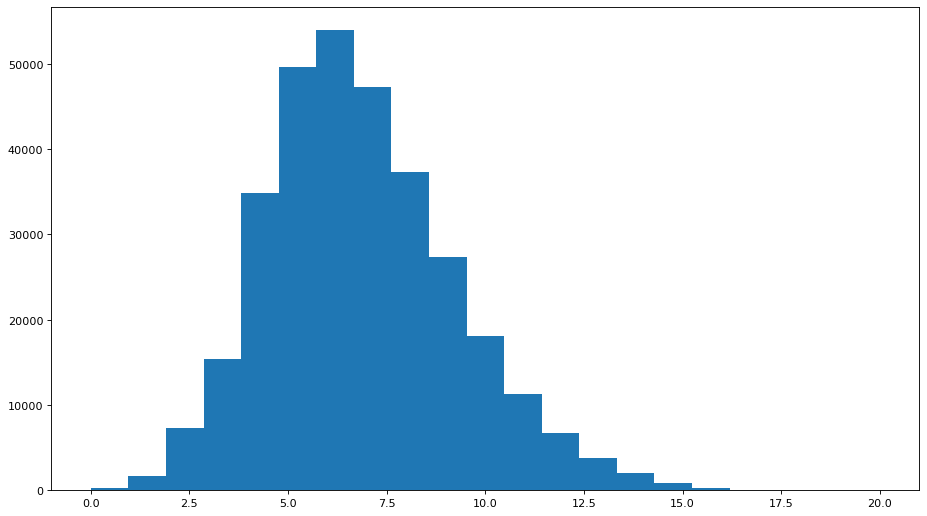

In [21]:
figure(figsize=(14, 8), dpi=80)
plt.hist(list(df['Mgltools_nrb']), bins = df['Mgltools_nrb'].max() - df['Mgltools_nrb'].min() + 1)

In [27]:
nrb = list(df['Mgltools_nrb'])
molwt = list(df['molwt'])
energy = list(df['mgltools_energy'])

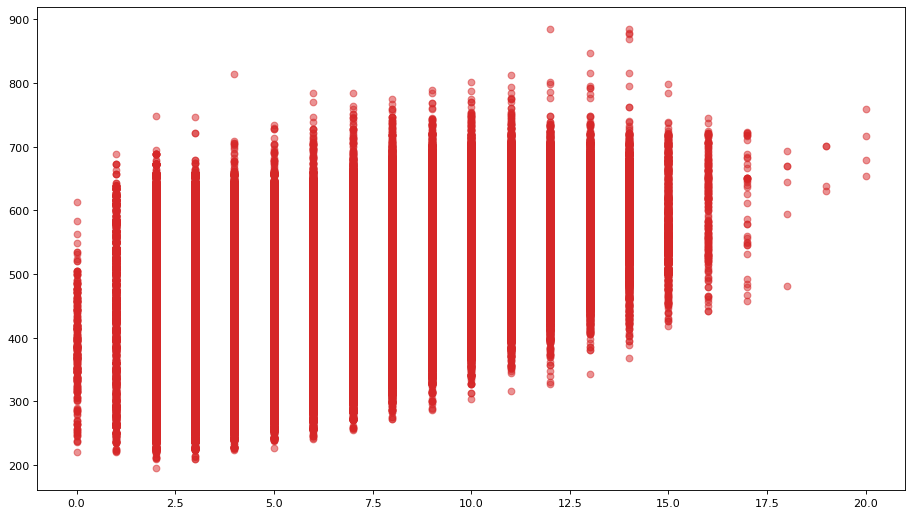

In [28]:
figure(figsize=(14, 8), dpi=80)   
plt.scatter(nrb, molwt, alpha=0.5, c = '#d62728')
plt.show()

In [29]:
df_2 = df[df['mgltools_energy'] < -5]
nrb_2 = list(df_2['Mgltools_nrb'])
molwt_2 = list(df_2['molwt'])
energy_2 = list(df_2['mgltools_energy'])

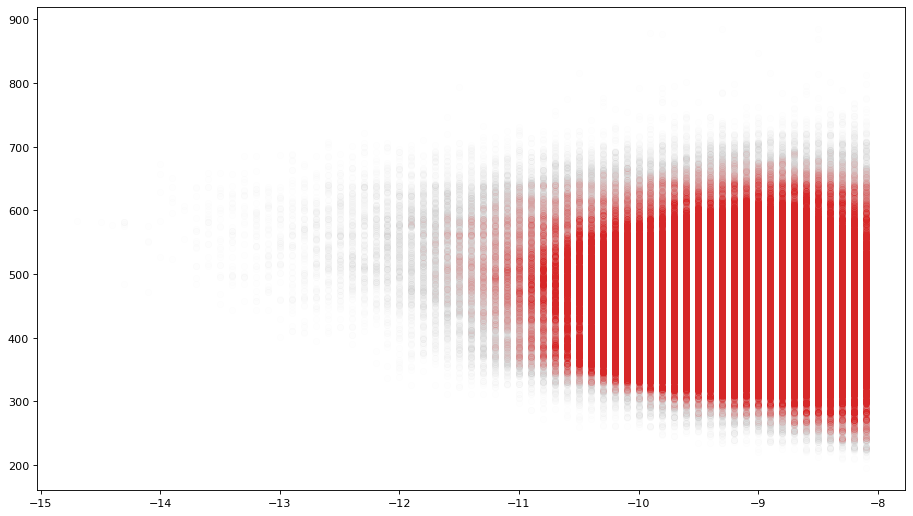

In [30]:
figure(figsize=(14, 8), dpi=80)    
plt.scatter(energy_2, molwt_2, alpha=0.002, c = '#d62728')
plt.show()

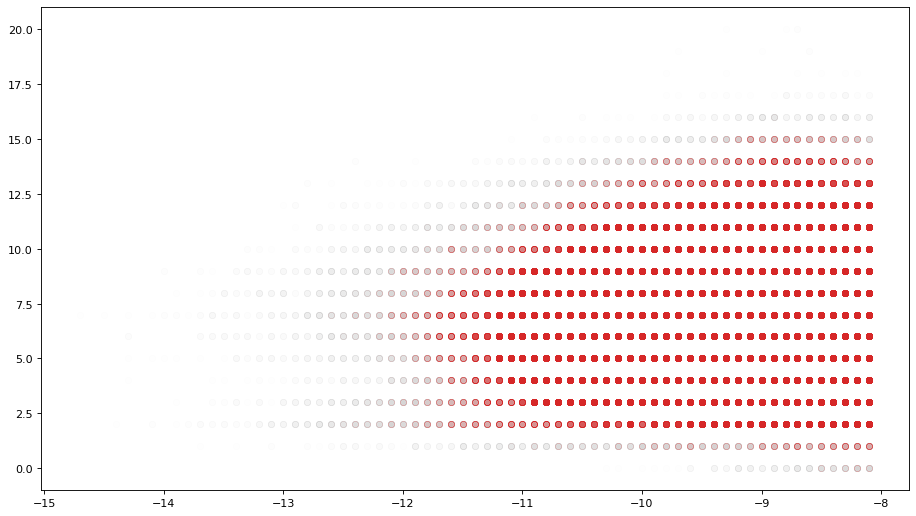

In [31]:
figure(figsize=(14, 8), dpi=80)    
plt.scatter(energy_2, nrb_2, alpha=0.002, c = '#d62728')
plt.show()

In [ ]:
df.to_csv('all.csv', index=False)